In [2]:
import tmm

from numpy import pi, linspace, inf, array
import numpy as np
import math
from scipy.interpolate import interp1d
from scipy.integrate import quad
import time
import matplotlib.pyplot as plt
%matplotlib inline

degree = pi/180

In [3]:
# generate nk for spatial KK stack

d = 0
nb = 1.7
#a = 2*nb**2
#a = 1
#pol = 'p'
#gam = 0.5

def eps(x, a, gam, nb):
    return nb**2 - 0.5 * a * gam / ((x-d/2) + 1j*gam) - 0.5 * a * gam / ((x+d/2) + 1j*gam)

'''
xq = np.concatenate((linspace(d/2,d/2+10*gam,15), linspace(d/2+10*gam,d/2+50*gam,10) , linspace(d/2+50*gam,d/2+200*gam,5)))
xq = np.unique(np.concatenate((xq, -xq + d)))
xq = np.unique(np.concatenate((-xq, xq)))

eq = interp1d(xq,eps(xq,a,gam,nb),kind='nearest')

d_list = np.diff(xq)
d_list[-1] = inf
d_list[0] = inf

n_list = np.sqrt(eq(xq[:-1]))
#n_list[-1] = np.real(np.sqrt(eq(xq[-1])))
#n_list[0] = np.real(np.sqrt(eq(xq[0])))
n_list[-1] = nb
n_list[0] = nb
'''

"\nxq = np.concatenate((linspace(d/2,d/2+10*gam,15), linspace(d/2+10*gam,d/2+50*gam,10) , linspace(d/2+50*gam,d/2+200*gam,5)))\nxq = np.unique(np.concatenate((xq, -xq + d)))\nxq = np.unique(np.concatenate((-xq, xq)))\n\neq = interp1d(xq,eps(xq,a,gam,nb),kind='nearest')\n\nd_list = np.diff(xq)\nd_list[-1] = inf\nd_list[0] = inf\n\nn_list = np.sqrt(eq(xq[:-1]))\n#n_list[-1] = np.real(np.sqrt(eq(xq[-1])))\n#n_list[0] = np.real(np.sqrt(eq(xq[0])))\nn_list[-1] = nb\nn_list[0] = nb\n"

In [16]:
def generate_n_and_d(gam, a):
    xq = np.concatenate((linspace(d/2,d/2+10*gam,15), linspace(d/2+10*gam,d/2+50*gam,10) , linspace(d/2+50*gam,d/2+200*gam,5)))
    xq = np.unique(np.concatenate((xq, -xq + d)))
    xq = np.unique(np.concatenate((-xq, xq)))
    eq = interp1d(xq,eps(xq,a,gam,nb),kind='nearest')
    
    d_list = np.diff(xq)
    d_list[-1] = inf
    d_list[0] = inf
    
    n_list = np.sqrt(eq(xq[:-1]))
    #n_list[-1] = np.real(np.sqrt(eq(xq[-1])))
    #n_list[0] = np.real(np.sqrt(eq(xq[0])))
    n_list[-1] = nb
    n_list[0] = nb
    print(n_list)
    print(d_list)

    return (d_list, n_list)

In [17]:
d_list, n_list = generate_n_and_d(0.01, 10)

[1.7       +0.00000000e+00j 1.71800353+1.10210450e-04j
 1.72336732+1.85671109e-04j 1.73328328+3.76727766e-04j
 1.7578172 +1.13731980e-03j 1.76335145+1.36564938e-03j
 1.77005712+1.67034973e-03j 1.77835006+2.08971462e-03j
 1.78886932+2.68944289e-03j 1.80264998+3.59005513e-03j
 1.82148594+5.03261443e-03j 1.84878047+7.55886017e-03j
 1.89186794+1.26066863e-02j 1.96995699+2.51299652e-02j
 1.98882057+2.88227864e-02j 2.01050131+3.33954930e-02j
 2.035675  +3.91519844e-02j 2.065249  +4.65397267e-02j
 2.10046831+5.62394673e-02j 2.14308308+6.93276406e-02j
 2.19562028+8.75869541e-02j 2.26183193+1.14140440e-01j
 2.34742795+1.54850965e-01j 2.46113696+2.21709326e-01j
 2.61515255+3.41915268e-01j 2.81584396+5.83944041e-01j
 2.97612059+1.11245855e+00j 2.57868489+1.93897286e+00j
 1.58630288+2.08712399e+00j 0.98611143+1.66745385e+00j
 0.73457093+1.21725562e+00j 0.66589974+8.19428186e-01j
 0.73402864+4.95214308e-01j 0.8742673 +2.95294689e-01j
 1.00188151+1.91946544e-01j 1.10010953+1.35054638e-01j
 1.1752864

In [14]:
def TRA_func(d_list, n_list):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    delta_lamb = lambda_list[-1] - lambda_list[0]
    angle = 0
    T_list_LR = np.zeros_like(lambda_list)
    R_list_LR = np.zeros_like(lambda_list)
    A_list_LR = np.zeros_like(lambda_list)
    T_list_RL = np.zeros_like(lambda_list)
    R_list_RL = np.zeros_like(lambda_list)
    A_list_RL = np.zeros_like(lambda_list)
    for j, lamb in enumerate(lambda_list):
        T_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
        R_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
        A_list_LR[j] = 1 - T_list_LR[j] - R_list_LR[j]

        T_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['T']
        R_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['R']
        A_list_RL[j] = 1 - T_list_RL[j] - R_list_RL[j]

    return (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL)

In [134]:
gam_list = np.linspace(0.001, 0.1, num=500)
A_list = np.linspace(1, 100, num=100)
FOM_bulk = np.zeros((len(gam_list), len(A_list)))
FOM_KK = np.zeros((len(gam_list), len(A_list)))

start = time.time()
for i, gam in enumerate(gam_list):
    for j, A in enumerate(A_list):
        d_list, n_list = generate_n_and_d(gam, A)
        (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(d_list, n_list)
        lambda_list = np.linspace(2,5,100)
        delta_lamb = lambda_list[-1] - lambda_list[0]
        
        losses_total = np.trapz(np.imag(n_list), x=d_list)
        trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
        emiss_bulk = 1 - trans_bulk
        FOM_bulk[i][j] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb
        
        FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
        FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
        FOM_KK[i][j] = max(FOM_LR, FOM_RL)
        print(i*j + j)

end = time.time()
print(f"Duration: {end - start} seconds")
np.savetxt("C:\\Users\\kl89\\MS Window Project\\FOM_KK_vs_AandGam.txt", FOM_KK)
np.savetxt("C:\\Users\\kl89\\MS Window Project\\FOM_bulk_vs_AandGam.txt", FOM_bulk)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
2
4
6
8
10
12
14
16
18
20
22
24
26
28
30
32
34
36
38
40
42
44
46
48
50
52
54
56
58
60
62
64
66
68
70
72
74
76
78
80
82
84
86
88
90
92
94
96
98
100
102
104
106
108
110
112
114
116
118
120
122
124
126
128
130
132
134
136
138
140
142
144
146
148
150
152
154
156
158
160
162
164
166
168
170
172
174
176
178
180
182
184
186
188
190
192
194
196
198
0
3
6
9
12
15
18
21
24
27
30
33
36
39
42
45
48
51
54
57
60
63
66
69
72
75
78
81
84
87
90
93
96
99
102
105
108
111
114
117
120
123
126
129
132
135
138
141
144
147
150
153
156
159
162
165
168
171
174
177
180
183
186
189
192
195
198
201
204
207
210
213
216
219
222
225
228
231
234
237
240
243
246
249
252
255
258
261
264
267
270
273
276
279
282
285
288
291
294
297
0
4

In [21]:
def generate_x_from_d(d_list):
    x_list = np.zeros(len(d_list)+1)
    curr = 0
    for i, thickness in enumerate(d_list):
        x_list[i+1] = curr + thickness
        curr = x_list[i+1]
    return x_list

d_list, n_list = generate_n_and_d(0.5, 1)
print(d_list)
x_list = generate_x_from_d(d_list[1:-1])
print(x_list.shape)
print(n_list[:-1].shape)

[1.7       +0.00000000e+00j 1.70180892+1.11259225e-05j
 1.70235116+1.87963287e-05j 1.70335759+3.83346363e-05j
 1.70586987+1.17195359e-04j 1.70644094+1.41119436e-04j
 1.70713502+1.73191598e-04j 1.70799663+2.17579124e-04j
 1.7090947 +2.81497677e-04j 1.71054189+3.78336996e-04j
 1.7125358 +5.35278529e-04j 1.71545734+8.14632504e-04j
 1.72014606+1.38652095e-03j 1.7288777 +2.86341541e-03j
 1.73103108+3.31151480e-03j 1.73352676+3.87312640e-03j
 1.73645186+4.58986038e-03j 1.73992507+5.52415304e-03j
 1.74411189+6.77302983e-03j 1.74924899+8.49363898e-03j
 1.75568439+1.09534318e-02j 1.76394438+1.46357501e-02j
 1.77484179+2.04807823e-02j 1.7896183 +3.04901339e-02j
 1.80987637+4.94045117e-02j 1.83516394+8.95993683e-02j
 1.84262248+1.79679280e-01j 1.72454637+2.89931317e-01j
 1.56893519+2.11022789e-01j 1.55926959+1.05452919e-01j
 1.58428965+5.64392112e-02j 1.60603559+3.39754000e-02j
 1.62199209+2.24108050e-02j 1.63369647+1.58025983e-02j
 1.64250704+1.17081807e-02j 1.64932752+9.00821044e-03j
 1.6547418

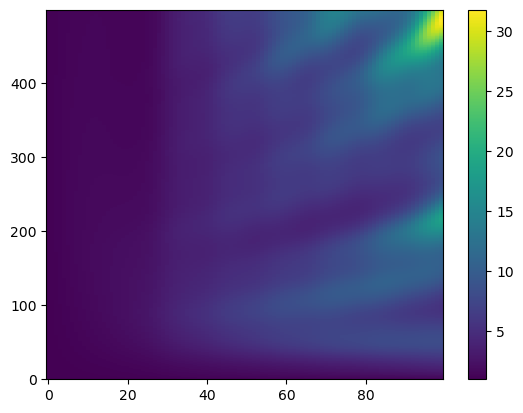

In [184]:
plt.figure()
plt.imshow(FOM_KK/FOM_bulk, interpolation='none', aspect='auto', origin='lower')
ax = plt.gca()
plt.colorbar()
np.savetxt("C:\\Users\\kl89\\MS Window Project\\FOM_bulk_vs_AandGam.txt", FOM_bulk)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

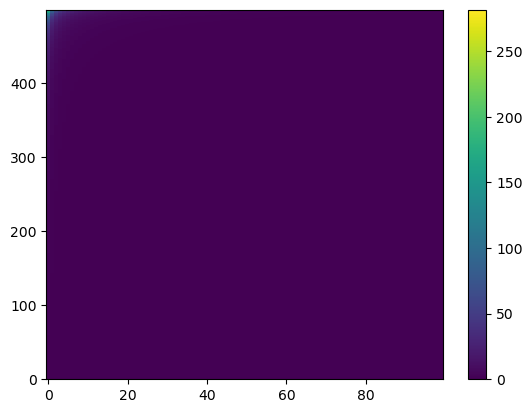

In [154]:
for i, gam in enumerate(gam_list):
    for j, A in enumerate(A_list):
        d_list, n_list = generate_n_and_d(gam, A)
        x_list = generate_x_from_d(d_list[1:-1])
        losses_total = np.trapz(np.imag(n_list[:-1]), x=x_list)

        lambda_list = np.linspace(2,5,100)
        delta_lamb = lambda_list[-1] - lambda_list[0]
        trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
        emiss_bulk = 1 - trans_bulk
        FOM_bulk[i][j] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb
        print(i*len(A_list) + j)

In [25]:
d_list, n_list = generate_n_and_d(0.01, 10)
x_list = generate_x_from_d(d_list[1:-1])
losses_total = np.trapz(np.imag(n_list[:-1]), x=x_list)

lambda_list = np.linspace(2,5,100)
delta_lamb = lambda_list[-1] - lambda_list[0]
trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
emiss_bulk = 1 - trans_bulk
curr_bulk = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb
print(curr_bulk)

[1.7       +0.00000000e+00j 1.71800353+1.10210450e-04j
 1.72336732+1.85671109e-04j 1.73328328+3.76727766e-04j
 1.7578172 +1.13731980e-03j 1.76335145+1.36564938e-03j
 1.77005712+1.67034973e-03j 1.77835006+2.08971462e-03j
 1.78886932+2.68944289e-03j 1.80264998+3.59005513e-03j
 1.82148594+5.03261443e-03j 1.84878047+7.55886017e-03j
 1.89186794+1.26066863e-02j 1.96995699+2.51299652e-02j
 1.98882057+2.88227864e-02j 2.01050131+3.33954930e-02j
 2.035675  +3.91519844e-02j 2.065249  +4.65397267e-02j
 2.10046831+5.62394673e-02j 2.14308308+6.93276406e-02j
 2.19562028+8.75869541e-02j 2.26183193+1.14140440e-01j
 2.34742795+1.54850965e-01j 2.46113696+2.21709326e-01j
 2.61515255+3.41915268e-01j 2.81584396+5.83944041e-01j
 2.97612059+1.11245855e+00j 2.57868489+1.93897286e+00j
 1.58630288+2.08712399e+00j 0.98611143+1.66745385e+00j
 0.73457093+1.21725562e+00j 0.66589974+8.19428186e-01j
 0.73402864+4.95214308e-01j 0.8742673 +2.95294689e-01j
 1.00188151+1.91946544e-01j 1.10010953+1.35054638e-01j
 1.1752864

[1.7       +0.00000000e+00j 1.71800353+1.10210450e-04j
 1.72336732+1.85671109e-04j 1.73328328+3.76727766e-04j
 1.7578172 +1.13731980e-03j 1.76335145+1.36564938e-03j
 1.77005712+1.67034973e-03j 1.77835006+2.08971462e-03j
 1.78886932+2.68944289e-03j 1.80264998+3.59005513e-03j
 1.82148594+5.03261443e-03j 1.84878047+7.55886017e-03j
 1.89186794+1.26066863e-02j 1.96995699+2.51299652e-02j
 1.98882057+2.88227864e-02j 2.01050131+3.33954930e-02j
 2.035675  +3.91519844e-02j 2.065249  +4.65397267e-02j
 2.10046831+5.62394673e-02j 2.14308308+6.93276406e-02j
 2.19562028+8.75869541e-02j 2.26183193+1.14140440e-01j
 2.34742795+1.54850965e-01j 2.46113696+2.21709326e-01j
 2.61515255+3.41915268e-01j 2.81584396+5.83944041e-01j
 2.97612059+1.11245855e+00j 2.57868489+1.93897286e+00j
 1.58630288+2.08712399e+00j 0.98611143+1.66745385e+00j
 0.73457093+1.21725562e+00j 0.66589974+8.19428186e-01j
 0.73402864+4.95214308e-01j 0.8742673 +2.95294689e-01j
 1.00188151+1.91946544e-01j 1.10010953+1.35054638e-01j
 1.1752864

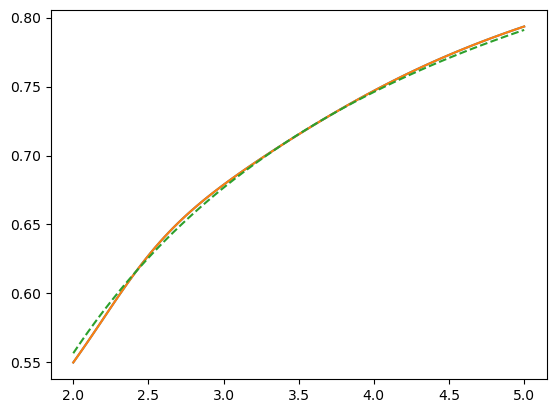

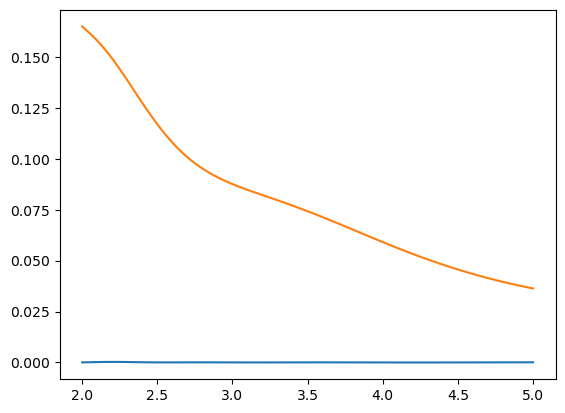

In [27]:
d_list, n_list = generate_n_and_d(0.01, 10)
(T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(d_list, n_list)
lambda_list = np.linspace(2,5,100)
delta_lamb = lambda_list[-1] - lambda_list[0]

FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
curr_FOM = max(FOM_LR, FOM_RL)
print(curr_FOM)
plt.plot(lambda_list, T_list_LR)
plt.plot(lambda_list, T_list_RL)
plt.plot(lambda_list, trans_bulk, '--')
plt.figure()
plt.plot(lambda_list, R_list_LR)
plt.plot(lambda_list, R_list_RL)

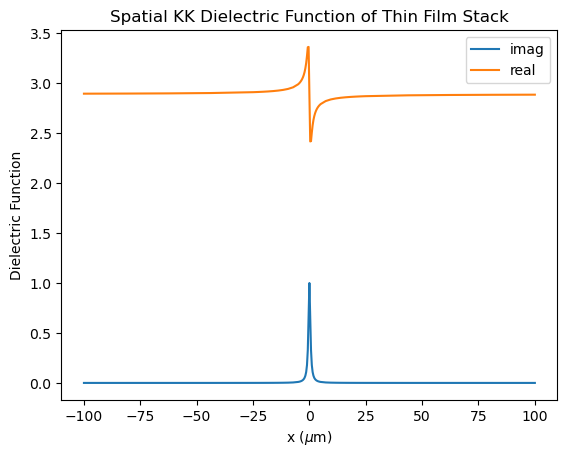

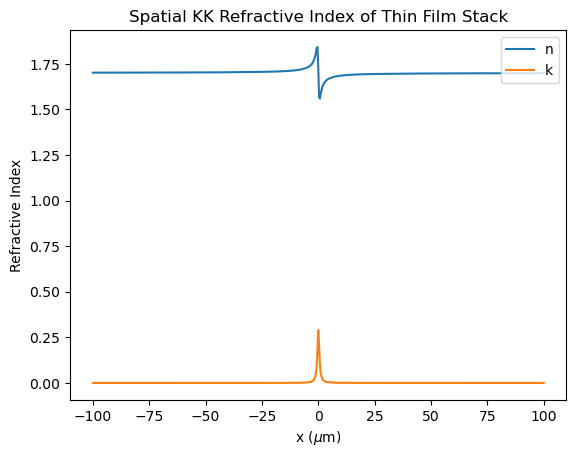

In [51]:
# plot dielectric function and refractive index

nkq = interp1d(xq,np.sqrt(eps(xq,a,gam,nb)),kind='nearest')

plt.figure(1)
#plt.plot(x_list, lorentzian_imag(x_list, x0, a, gam))
#plt.plot(x_list, lorentzian_real(x_list, x0, a, gam))
plt.plot(xq, np.imag(eq(xq)), label='imag')
plt.plot(xq, np.real(eq(xq)), label='real')
#plt.hlines(1,1,20)  # Draw a horizontal line
#plt.eventplot(xq, orientation='horizontal', colors='b')
plt.xlabel('x ($\mu$m)')
plt.ylabel('Dielectric Function')
plt.title('Spatial KK Dielectric Function of Thin Film Stack');
plt.legend(loc='upper right')

plt.figure(2)
plt.plot(xq, np.real(nkq(xq)), label='n')
plt.plot(xq, np.imag(nkq(xq)), label='k')
plt.xlabel('x ($\mu$m)')
plt.ylabel('Refractive Index')
plt.title('Spatial KK Refractive Index of Thin Film Stack');
plt.legend(loc='upper right')

In [7]:
# wavelength dependence calculation of RTA using coherent TMM function (coh_tmm and coh_tmm_reverse)

pol = 'p'
lambda_list = linspace(2,5,100)
angle = 0

T_list = []
R_list = []
for lamb in lambda_list:
    T_list.append(tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T'])
    R_list.append(tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R'])

T_reverse_list = []
R_reverse_list = []
for lamb in lambda_list:
    T_reverse_list.append(tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['T'])
    R_reverse_list.append(tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['R'])

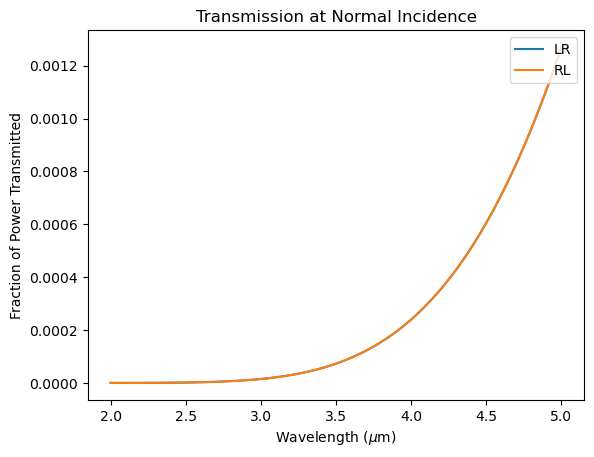

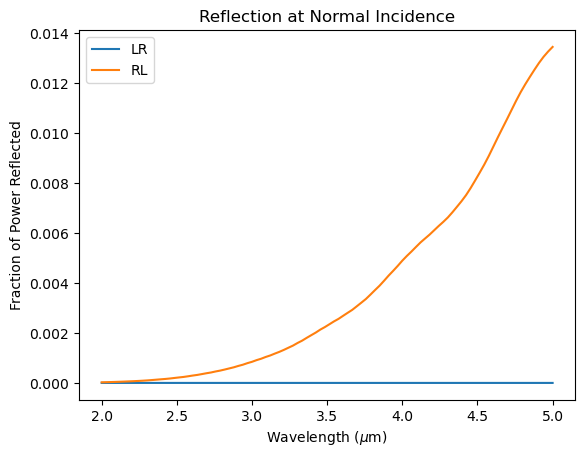

In [9]:
# plotting RTA forwards and backwards

plt.figure()
plt.plot(lambda_list,T_list, label='LR')
plt.plot(lambda_list,T_reverse_list, label='RL')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power Transmitted')
plt.title('Transmission at Normal Incidence');
plt.legend(loc='upper right')

plt.figure()
plt.plot(lambda_list,R_list, label='LR')
plt.plot(lambda_list,R_reverse_list, label='RL')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power Reflected')
plt.title('Reflection at Normal Incidence'); 
plt.legend(loc='upper left')

In [6]:
def lorentzian(x):
    return 2 * 500**2 / ( 500**2 + ( x - 5000 )**2)
I = quad(lorentzian, 0, 10000)
print(I[0]/10000)

0.294225534860747


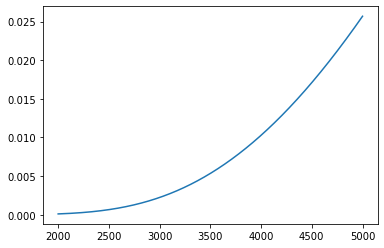

In [7]:
#k_av = I[0]/10000
k_av = 0.1457
A_arr = []
T_arr = []

lambda_list = linspace(2000,5000,3000)

for lambda_vac in lambda_list:
    A_curr = 1-math.exp(-4*pi*k_av*10000/lambda_vac)
    A_arr.append(A_curr)
    T_arr.append(1-A_curr)

plt.figure()
plt.plot(lambda_list, T_arr)


In [45]:
d = 10
arr = np.unique(np.concatenate((linspace(0, d/4, 5), linspace(d/4, d/2, 10))))
print(arr)
arrconc = np.unique(np.concatenate((arr, -arr + d)))
print(arrconc)
finalarrconc = np.unique(np.concatenate((-arrconc, arrconc)))
print(finalarrconc)

[0.         0.625      1.25       1.875      2.5        2.77777778
 3.05555556 3.33333333 3.61111111 3.88888889 4.16666667 4.44444444
 4.72222222 5.        ]
[ 0.          0.625       1.25        1.875       2.5         2.77777778
  3.05555556  3.33333333  3.61111111  3.88888889  4.16666667  4.44444444
  4.72222222  5.          5.27777778  5.55555556  5.83333333  6.11111111
  6.38888889  6.66666667  6.94444444  7.22222222  7.5         8.125
  8.75        9.375      10.        ]
[-10.          -9.375       -8.75        -8.125       -7.5
  -7.22222222  -6.94444444  -6.66666667  -6.38888889  -6.11111111
  -5.83333333  -5.55555556  -5.27777778  -5.          -4.72222222
  -4.44444444  -4.16666667  -3.88888889  -3.61111111  -3.33333333
  -3.05555556  -2.77777778  -2.5         -1.875       -1.25
  -0.625        0.           0.625        1.25         1.875
   2.5          2.77777778   3.05555556   3.33333333   3.61111111
   3.88888889   4.16666667   4.44444444   4.72222222   5.
   5.27777778  